In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
plt.style.use("../mpl_themes/jvc.mplstyle")
GALLERY = "/home/jvc/ZnO_database/gallery"

## Estrutura de Bandas e DOS


Post-Processing :: `"/home/jvc/ZnO_database/DFT_PBE/03_band_structure/pp_bands/ZnO_PBE_bands.dat.gnu"`

```Fortran
    Reading collected, re-writing distributed wavefunctions
     high-symmetry point:  0.0000 0.0000 0.0000   x coordinate   0.0000
     high-symmetry point:  0.5000 0.2887 0.0000   x coordinate   0.5774
     high-symmetry point:  0.5000 0.2887 0.3111   x coordinate   0.8884
     high-symmetry point:  0.0000 0.0000 0.3111   x coordinate   1.4658
     high-symmetry point:  0.0000 0.0000 0.0000   x coordinate   1.7768
     high-symmetry point:  0.6666 0.7697 0.0000   x coordinate   2.7951
     high-symmetry point:  0.6666 0.7697 0.3111   x coordinate   3.1061
     high-symmetry point:  0.0000 0.0000 0.3111   x coordinate   4.1244
```

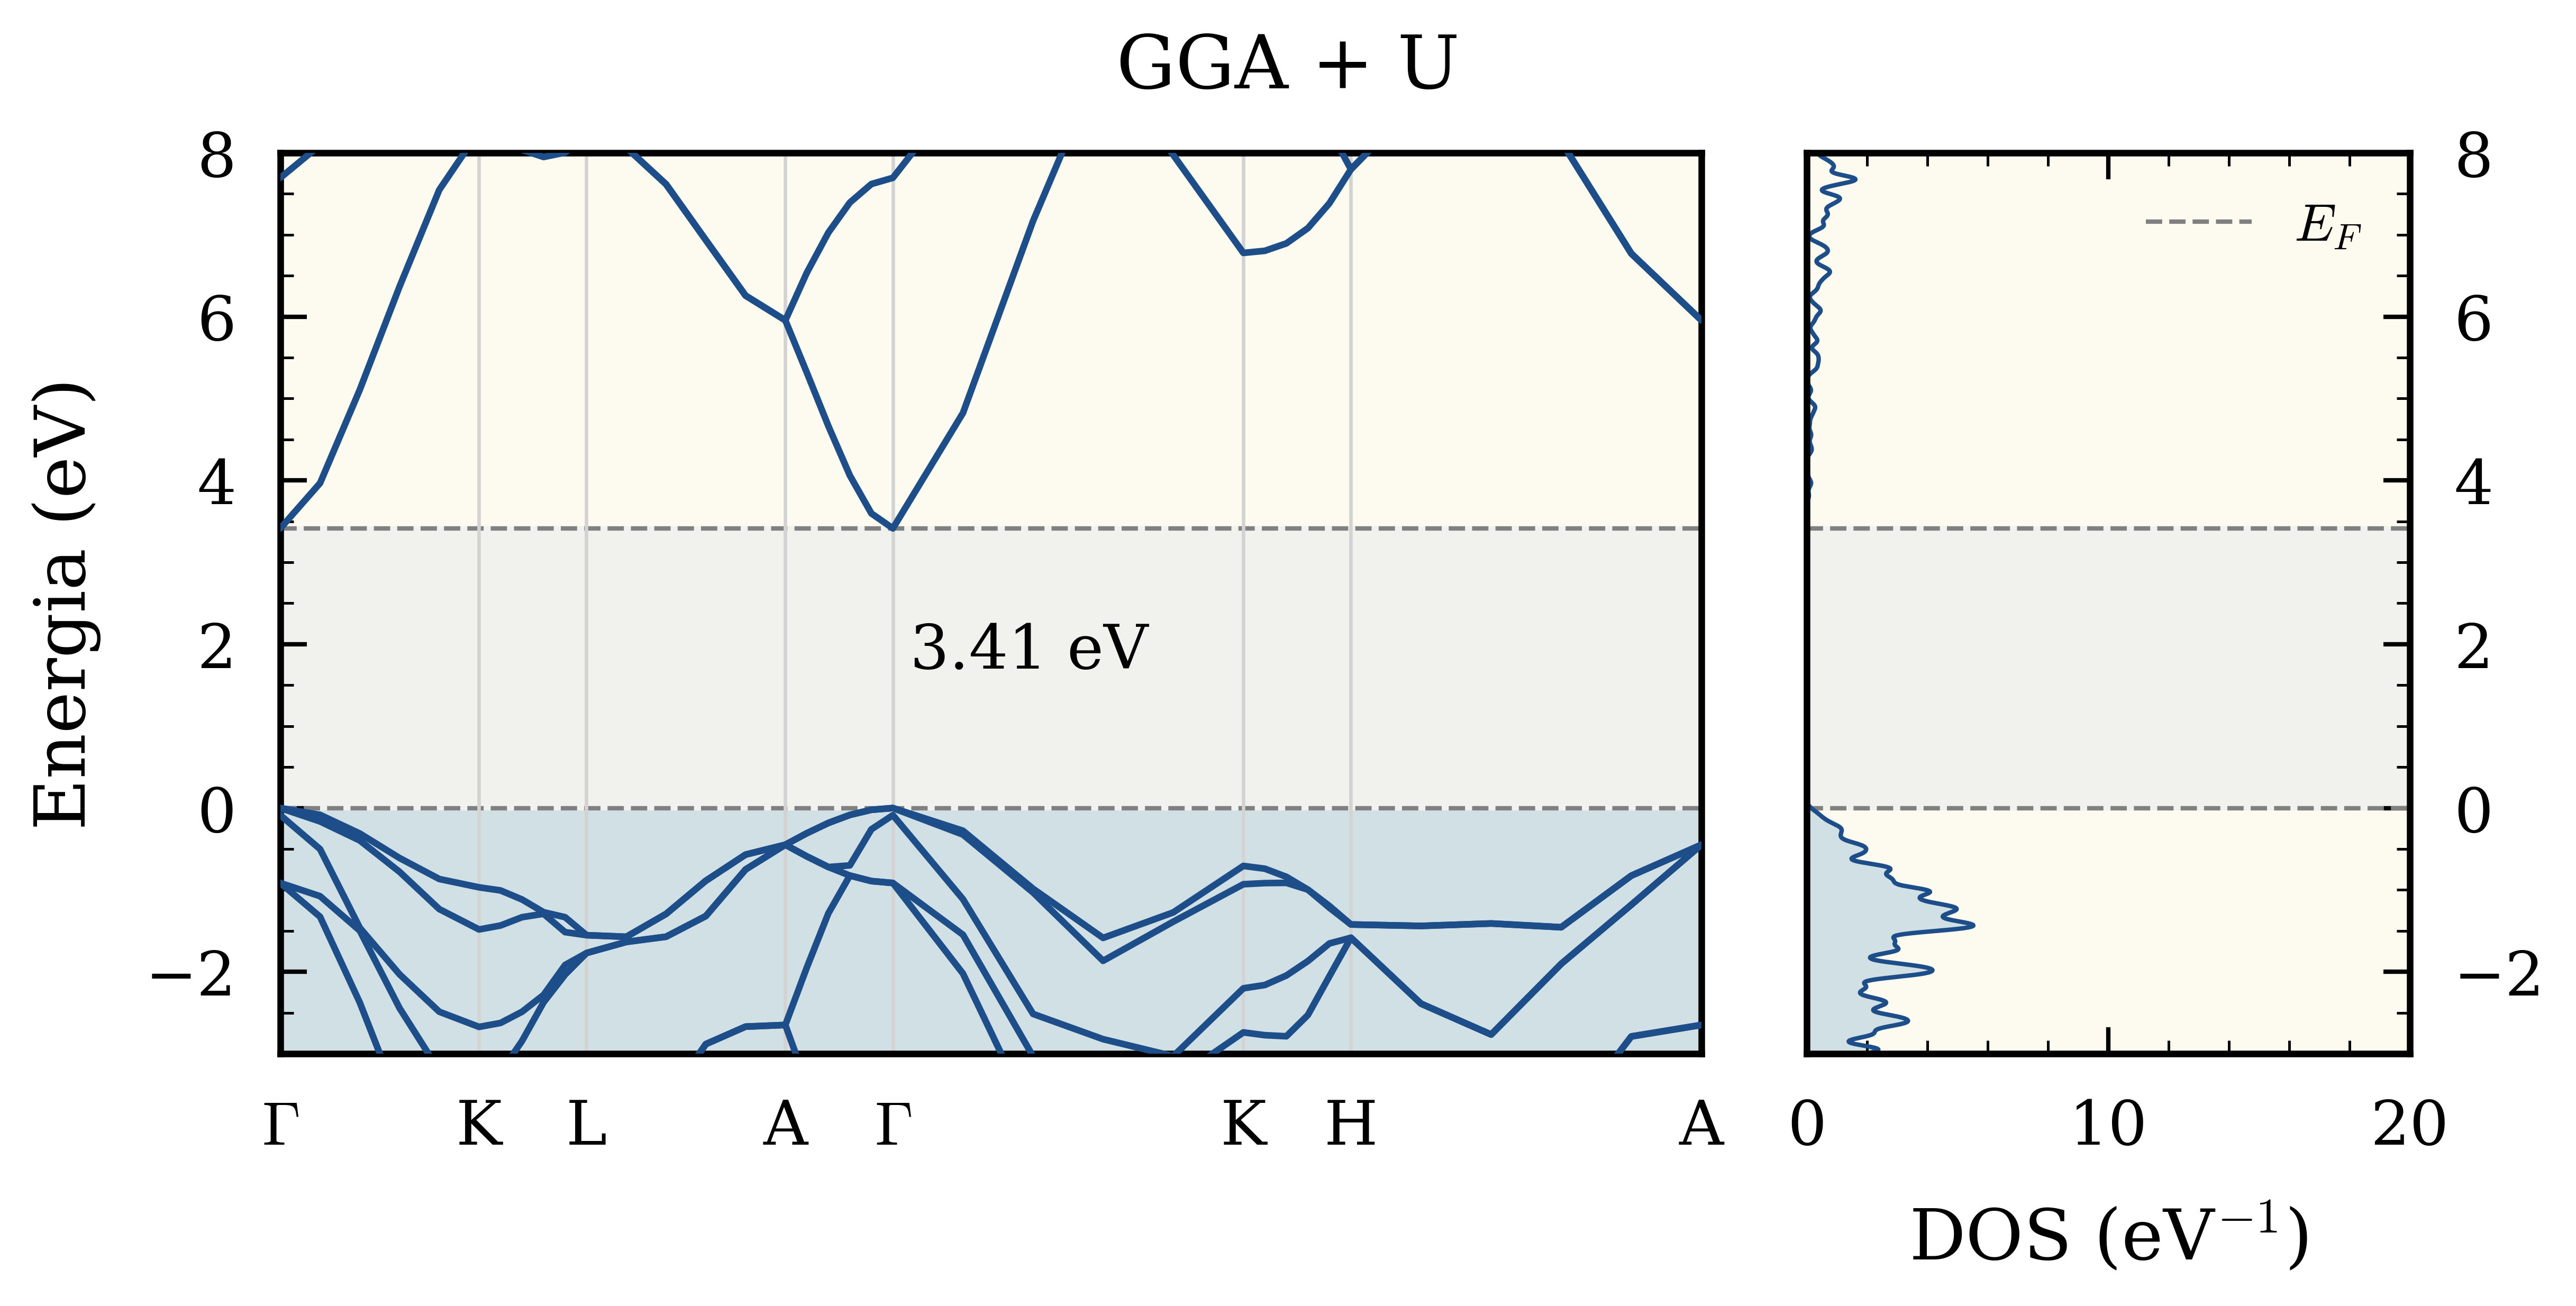

In [10]:
# ------------------------------------------------------------------------------
# File sensitive data:
# scf: high_occ, lowest_unocc
# nscf: high_sym_labels
# ppbands.out: high_sym_points

# Load 
bands_datapath = r"../DFT_PBEU/03_Bands/pp-bands/ZnO_PBEU_bands.dat.gnu"
bands = np.loadtxt(bands_datapath)

dos_datapath = r"../DFT_PBEU/04_DOS/03_ppdos/ZnO.dos.dat"
energy_d, dos, idos = np.loadtxt(dos_datapath,unpack=True)

k = np.unique(bands[:, 0])
energy_b = np.reshape(bands[:, 1], (-1, k.size))

high_sym_points = [0.0000, 0.5774, 0.8889, 1.4673, 1.7798, 2.7981, 3.1106, 4.1289] 
high_sym_labels = [r"$\Gamma$", r"K", "L", "A", r"$\Gamma$", "K", "H", "A"]
high_occ, lowest_unocc = 7.4991, 10.9134

################################################################################

# PLOT
BLUE = "#1D4E89"
fig, (ax_bands, ax_dos) = plt.subplots(
    ncols=2,
    figsize=(8, 4),
    dpi=600,
    gridspec_kw={"width_ratios": [3.3, 1.4], "wspace": 0.05},
    sharey=True,
    layout="constrained",
)

fig.suptitle("GGA + U")
E_cbm = lowest_unocc - high_occ  # valor do gap com Ef = 0

# Linha do nível de Fermi
for ax in (ax_bands, ax_dos):
    ax.axhline(0.0, ls="--", lw=1.0, color="gray", label=r"$E_F$", zorder=2)
    ax.axhline(E_cbm, ls="--", lw=1.0, color="gray")
    ax.axhspan(0, E_cbm, color="#F1F2EE")

ax_bands.text(x=high_sym_points[4] + 5e-2, y=E_cbm/2, s=f"{E_cbm:.2f} eV")

ax_bands.set_ylim(-3, 8)
ax_bands.set_xlim(k.min(), k.max())

ax_bands.set_ylabel("Energia (eV)")
ax_bands.set_xlabel("")

ax_bands.tick_params(axis="x", which="both", top=False, bottom=False)
ax_bands.tick_params(axis="both", which="both", top=False, bottom=False, right=False)
ax_bands.set_xticks(high_sym_points)
ax_bands.set_xticklabels(high_sym_labels)


for p in high_sym_points:
    ax_bands.axvline(p, color="lightgray", linewidth=0.8)

for band in range(len(energy_b)):
    ax_bands.plot(k, energy_b[band, :] - high_occ, linewidth=1.5, color=BLUE, zorder=3)


ax_bands.axhspan(0, -4, alpha=0.20, zorder=0)


# DENSIDADE DE ESTADOS
ax_dos.yaxis.set_ticks_position("right")
ax_dos.yaxis.set_label_position("right")
ax_dos.tick_params(axis="y", which="both", left=False)
ax_dos.set_xlabel(r"DOS (eV$^{-1}$)")
ax_dos.set_xlim(0, 20)


ax_dos.plot(dos, energy_d - high_occ, color=BLUE, linewidth=1.0)
ax_dos.fill_betweenx(
    (energy_d - high_occ),
    0.0,
    dos,
    where=((energy_d - high_occ) <= 0),
    alpha=0.20,
    interpolate=True,
)
ax.legend()

plt.savefig(f"{GALLERY}/bands_and_dos_PBEUNC.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Densidade de Estados Projetada

_setup do pós-processamento_ com `dos.x`e `projwfc.x` 

```Fortran
degauus = 0.005
DeltaE = 0.01
```

In [11]:
def data_loader(fname) -> tuple[np.ndarray, np.ndarray]:
    """Load Energy and Ldos columns total contribution for a given orbital"""
    data = np.loadtxt(fname)
    energy = data[:, 0]
    pdos = data[:, 1]

    return energy, pdos

In [13]:
ppdos_folder = "../DFT_PBEU/04_DOS/03_ppdos"

# Total
_, dos_tot = data_loader(f"{ppdos_folder}/ZnO_PBEU.pdos_tot")

# Zn d
e , zn1_d = data_loader(f"{ppdos_folder}/ZnO_PBEU.pdos_atm#1(Zn)_wfc#3(d)")
_ , zn2_d = data_loader(f"{ppdos_folder}/ZnO_PBEU.pdos_atm#2(Zn)_wfc#3(d)")

zn_d = zn1_d + zn2_d

# O p
_, o1_p = data_loader(f"{ppdos_folder}/ZnO_PBEU.pdos_atm#3(O)_wfc#2(p)")
_, o2_p = data_loader(f"{ppdos_folder}/ZnO_PBEU.pdos_atm#4(O)_wfc#2(p)")
o_p = o1_p + o2_p



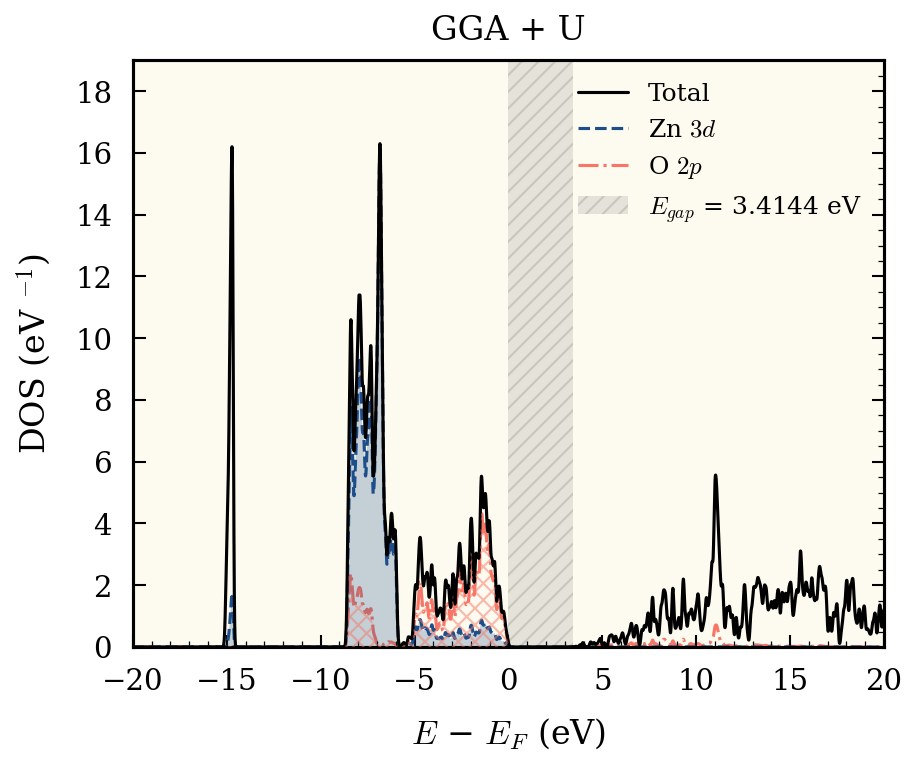

In [15]:
EFermi = 7.499 # /home/jvc/ZnO_database/DFT_PBEU/04_DOS/03_pp_dos/ZnO.dos.dat
Eg = 3.4144

LIGHT_RED = "#F87666"
DARK_BLUE = "#1D4E89"
GREEN = "#629677"

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.set_title("GGA + U", pad=10)
ax.set_ylabel(r"DOS (eV $^{-1}$)")
ax.set_xlabel("$E$ − $E_F$ (eV)")
ax.set_xlim(-20, 20)
ax.set_ylim(0, 19)
# ax.set_yticks([])
ax.tick_params(which="both", top=False)
ax.tick_params(axis='y', which="minor", left=False)

ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.xaxis.set_major_locator(plt.MultipleLocator(5))

E = e - EFermi

ax.plot(E, dos_tot, color="black", label="Total", lw=1.5, zorder=3)
ax.plot(
    E,
    zn_d,
    color=DARK_BLUE,
    label="Zn $3d$",
    lw=1.5,
    ls="--",
    zorder=2,
)
ax.plot(
    E,
    o_p,
    color=LIGHT_RED,
    label="O $2p$",
    lw=1.5,
    ls="dashdot",
    zorder=1,
)

# Occupied States
to_fill = E < 0

# ax.fill_between(E, 0, dos_tot, where=to_fill, facecolor="gray", alpha=0.25, zorder=1)
ax.fill_between(E, 0, zn_d, where=to_fill, facecolor=DARK_BLUE, alpha=0.25, zorder=2)
ax.fill_between(E, 0, o_p, where=to_fill, facecolor="none", edgecolor=LIGHT_RED, hatch="xxx", lw=0.0, alpha=0.5, zorder=3)

# Fermi vertical line
# ax.axvline(0, linestyle="--", linewidth=0.8, label=r"$E_F$", color=GREEN, zorder=10)

span_label = r"$E_{gap}$ = " + f"{Eg} eV"
ax.axvspan(
    0.0,
    Eg,
    facecolor="gray",  # não pinta sólido
    edgecolor="0.35",  # cor da hachura/borda (cinza)
    hatch="///",
    lw=0.0,
    zorder=0,
    alpha=0.2,
    label=span_label
)

ax.legend()
# Save Individual Contributions
# plt.savefig(f"{GALLERY}/O_p_states_pdos_PBENC.pdf", format="pdf")
# plt.savefig(f"{GALLERY}/Zn_d_states_pdos_PBENC.pdf", format="pdf")

plt.savefig(f"{GALLERY}/pdos-PBEUNC.pdf")
plt.show()


__Examplo__: https://pranabdas.github.io/espresso/hands-on/pdos/
```python
plt.fill_between(energy, 0, pdos_s, where=(energy < 7.9421), facecolor='#006699', alpha=0.25)
plt.fill_between(energy, 0, pdos_p, where=(energy < 7.9421), facecolor='r', alpha=0.25)
plt.fill_between(energy, 0, pdos_tot, where=(energy < 7.9421), facecolor='k', alpha=0.25)
```